In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("dataset final.csv",sep =",",decimal =",")
print(data.dtypes)
data.head()



Currency      str
Date          str
Open          str
High          str
Low           str
Close         str
Volume        str
Market Cap    str
dtype: object


,Currency,Date,Open,High,Low,Close,Volume,Market Cap
0,tezos,"Dec 04, 2019",1.29,1.32,1.25,1.25,"46,048,752","824,588,509"
1,tezos,"Dec 03, 2019",1.24,1.32,1.21,1.29,"41,462,224","853,213,342"
2,tezos,"Dec 02, 2019",1.25,1.26,1.20,1.24,"27,574,097","817,872,179"
3,tezos,"Dec 01, 2019",1.33,1.34,1.25,1.25,"24,127,567","828,296,390"
4,tezos,"Nov 30, 2019",1.31,1.37,1.31,1.33,"28,706,667","879,181,680"


In [3]:
# Je dois remplacer les données "Open" et "Close" en float

data["Open"] = data["Open"].str.replace(',', '').astype(float)
data["Close"] = data["Close"].str.replace(',', '').astype(float)


In [4]:
# Voir le type des données 
data.dtypes

Currency          str
Date              str
Open          float64
High              str
Low               str
Close         float64
Volume            str
Market Cap        str
dtype: object

In [5]:
# Vérifier s'il y a des zéros dans la colonne 'Open'
print((data["Open"] <= 0).sum())
print((data["Close"]<=0).sum())

0
0


In [6]:
## On calcule les rendements pour chaque ligne de chaque action

data["Rendement"] = np.log(data["Close"]/data["Open"])
data.head(5)

,Currency,Date,Open,High,Low,Close,Volume,Market Cap,Rendement
0,tezos,"Dec 04, 2019",1.29,1.32,1.25,1.25,"46,048,752","824,588,509",-0.031499
1,tezos,"Dec 03, 2019",1.24,1.32,1.21,1.29,"41,462,224","853,213,342",0.039531
2,tezos,"Dec 02, 2019",1.25,1.26,1.20,1.24,"27,574,097","817,872,179",-0.008032
3,tezos,"Dec 01, 2019",1.33,1.34,1.25,1.25,"24,127,567","828,296,390",-0.062035
4,tezos,"Nov 30, 2019",1.31,1.37,1.31,1.33,"28,706,667","879,181,680",0.015152


In [7]:
## séparer les différentes valeurs
actions = data["Currency"].unique()
list(actions)

['tezos',
 'binance-coin',
 'eos',
 'bitcoin',
 'tether',
 'xrp',
 'bitcoin-cash',
 'stellar',
 'litecoin',
 'ethereum',
 'cardano',
 'bitcoin-sv']

In [8]:
data.dtypes

Currency          str
Date              str
Open          float64
High              str
Low               str
Close         float64
Volume            str
Market Cap        str
Rendement     float64
dtype: object

In [9]:
data_frame = {}
for i in actions:
    data_frame[i] = data.loc[data["Currency"]==i,"Rendement"].reset_index(drop=True)
    df = pd.DataFrame(data_frame)
df.head()

,tezos,binance-coin,eos,bitcoin,tether,xrp,bitcoin-cash,stellar,litecoin,ethereum,cardano,bitcoin-sv
0,-0.031499,-0.004571,-0.018692,-0.009347,0.00995,-0.015939,-0.016068,-0.008946,-0.004636,-0.007941,-0.013305,-0.005850
1,0.039531,0.007869,0.003711,-0.000523,0.00000,0.001611,-0.012326,-0.001107,-0.008776,-0.007407,-0.003423,-0.046425
2,-0.008032,-0.020848,-0.032910,-0.013841,0.00000,-0.026093,-0.003333,-0.035388,-0.039162,-0.014122,-0.040073,-0.037586
3,-0.062035,-0.015365,0.007220,-0.019650,0.00000,-0.005016,-0.012961,-0.028330,0.005254,-0.008562,-0.020972,-0.032174
4,0.015152,-0.033774,-0.014389,-0.025361,0.00000,-0.016457,-0.027351,0.005633,-0.029673,-0.017867,-0.024219,-0.016213


In [10]:
mat_rend = np.array(df)
mat_rend

array([[-0.03149867, -0.00457069, -0.01869213, ..., -0.00794113,
        -0.01330503, -0.00585041],
       [ 0.03953084,  0.00786889,  0.00371058, ..., -0.00740694,
        -0.00342268, -0.04642527],
       [-0.00803217, -0.02084766, -0.03290973, ..., -0.01412227,
        -0.04007334, -0.03758557],
       ...,
       [-0.02298952, -0.02298952, -0.02298952, ..., -0.03533937,
        -0.02298952, -0.02298952],
       [ 0.00228572,  0.00228572,  0.00228572, ...,  0.07243828,
         0.00228572,  0.00228572],
       [ 0.01156082,  0.01156082,  0.01156082, ..., -0.0080888 ,
         0.01156082,  0.01156082]], shape=(2412, 12))

In [11]:
type(mat_rend)

numpy.ndarray

In [12]:
esperence = np.mean(mat_rend,axis=0)
esperence.shape

(12,)

In [13]:
# On centre nos données
mat_rend_cent = mat_rend-esperence
mat_rend_cent.shape

(2412, 12)

In [14]:
# On calcule la matrice de covariance
n = mat_rend_cent.shape[0]
mat_cov = ((mat_rend_cent.T)@(mat_rend_cent))/(n-1)
mat_cov

array([[0.00625482, 0.0028263 , 0.00276966, 0.00157697, 0.00085111,
        0.0024476 , 0.0014992 , 0.00512929, 0.00268215, 0.00172544,
        0.00518728, 0.00286808],
       [0.0028263 , 0.00579494, 0.00442978, 0.00188716, 0.00068594,
        0.00160643, 0.00150676, 0.00278957, 0.00377929, 0.00194097,
        0.0028976 , 0.00567094],
       [0.00276966, 0.00442978, 0.0054389 , 0.00190063, 0.00067748,
        0.00192521, 0.00182113, 0.0030403 , 0.00393985, 0.00213964,
        0.00316444, 0.00448433],
       [0.00157697, 0.00188716, 0.00190063, 0.00182916, 0.00059547,
        0.00119224, 0.00122103, 0.00158432, 0.0018299 , 0.00159994,
        0.00165611, 0.00193688],
       [0.00085111, 0.00068594, 0.00067748, 0.00059547, 0.00193647,
        0.00191189, 0.00192377, 0.00084205, 0.00070017, 0.00059346,
        0.00083397, 0.00068542],
       [0.0024476 , 0.00160643, 0.00192521, 0.00119224, 0.00191189,
        0.00515258, 0.00274548, 0.00284382, 0.00170326, 0.00144109,
        0.0030013 ,

In [15]:
mat_cov.shape

(12, 12)

### On résoud le problème d'optimisation maintenant

In [16]:
## solutions initiales et intervalles
sol_initial = np.array([1/12 for i in range(12)])
intervalle = [(0,1)]*12

### Premier cas; à la fois on maximise le rendement et on minimise le risque

In [17]:
## Maintenant on établit le probleme d'optimisation
# 1 Maximiser le rendement sous une contrainte de budgétisation
def gain(X):
    risque = (X.T)@(mat_cov)@(X)
    val_ajouté = (X.T)@esperence
    return -(val_ajouté-risque)
def contraint1(X):
    return (np.sum(X)-1)


In [18]:
## Mise en application
contr = [{"fun":contraint1,"type":"eq"}]
res = minimize(fun=gain,x0=sol_initial,constraints=contr,bounds=intervalle,method="SLSQP")


In [19]:
print(f"{np.round(res.x, 4)}")
sol_mult_obj = res.x

[0.     0.1229 0.     0.4284 0.2506 0.     0.     0.     0.     0.1746
 0.     0.0236]


### Deuxième cas : Minimiser le risque sous la contrainte de budgétisation. On ne se soucie pas du rendement.

In [20]:
# La seule contrainte est celle de budgétisation
def risque(X):
    return (X.T)@mat_cov@X

In [21]:
## aplication
res2 = minimize(fun=risque,x0=sol_initial,constraints=contr,bounds=intervalle,method="SLSQP")

In [22]:
## Là on obtient les pondérations qui minimise le risque sans contrainte sur le rendement

print(np.round(res2.x, 4))

[0.     0.     0.     0.3722 0.4832 0.     0.     0.015  0.0009 0.1287
 0.     0.    ]


### Troisième cas: Maximiser le gain sans contrainte de risque

In [23]:
## 3 La on maximise le gain sans se soucier du risque
def gain_obtenu(X):
    return -X.T@esperence

## Application
res3 = minimize(fun=gain_obtenu,x0=sol_initial,constraints=contr,bounds=intervalle,method="SLSQP")

In [24]:
## Là on obtient les pondérations qui maximise le gain sans contrainte sur le risque
print(np.round(res3.x, 4))

[0.     0.5507 0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.4493]


### Troisième cas: Minimiser le risque pour un rendement donné

In [36]:
## prenons l'exemple d'un rendement de 0.025
## Application
res4 = minimize(fun=risque,x0=sol_initial,constraints=[{"fun": lambda X: X.T @ esperence - 0.0025, "type": "eq"},{"fun":contraint1,"type":"eq"}],bounds=intervalle,method="SLSQP")



In [37]:
## La on obtient les pondérations qui minimise le risque pour un rendement voulu de 0.0025
print(np.round(res4.x, 4))

[0.     0.8359 0.     0.     0.     0.     0.     0.     0.     0.1641
 0.     0.    ]


## Tracer de la frontriere éfficiente

In [27]:

r_min = esperence.min() 
r_max = esperence.max()
rendement = np.linspace(r_min,r_max,100)
risk = []
for i in rendement:
    contraint5 = [{"fun": lambda X,i=i: X.T@esperence - i, "type": "eq"},{"fun": lambda X: np.sum(X) - 1,"type": "eq"}]
    res5 = minimize(fun=risque,x0=sol_initial,constraints=contraint5,bounds=intervalle,method="SLSQP")
    sol_efficiente = res5.x
    risk_min = sol_efficiente.T@mat_cov@sol_efficiente
    risk.append(risk_min)
risk_final = np.array(risk)


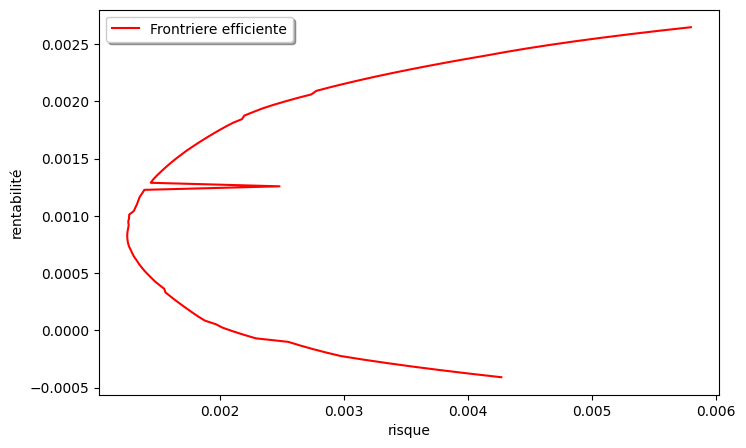

In [28]:
plt.figure(figsize=(8,5))
plt.plot(risk_final,rendement,label="Frontriere efficiente",color='red')
plt.xlabel("risque")
plt.ylabel('rentabilité')
plt.legend(loc="best",shadow=True)
plt.show()

### Conclusions


In [29]:
col = ['tezos','binance-coin','eos','bitcoin','tether','xrp','bitcoin-cash','stellar','litecoin','ethereum','cardano','bitcoin-sv']
poids = [x*100 for x in sol_mult_obj]
portefeuille = pd.DataFrame([poids],columns=col)
print(f"Pour minimiser les risque et à la fois maximiser le rendement on a:\nrendement attendu: {(res.x).T@esperence}\nrisque associé: {(res.x).T@mat_cov@(res.x)}\nEt comme poids pour le portefeuille on a:")

portefeuille

Pour minimiser les risque et à la fois maximiser le rendement on a:
rendement attendu: 0.0013878890676472671
risque associé: 0.0015163965510279491
Et comme poids pour le portefeuille on a:


,tezos,binance-coin,eos,bitcoin,tether,xrp,bitcoin-cash,stellar,litecoin,ethereum,cardano,bitcoin-sv
0,0.0,12.289712,9.215243e-17,42.835566,25.055892,5.926050e-16,0.0,0.0,0.0,17.458342,0.0,2.360488


In [30]:
## Pour minimiser le risque sans tenir compte du rendement on aura:
poids_2 = [x*100 for x in res2.x]
portefeuille_2 = pd.DataFrame([poids_2],columns=col)
print(f"Pour minimiser les risques sans se soucier du rendement on a:\nrendement attendu: {(res2.x).T@esperence}\nrisque associé: {(res2.x).T@mat_cov@(res2.x)}\nEt comme poids pour le portefeuille on a:")
portefeuille_2

Pour minimiser les risques sans se soucier du rendement on a:
rendement attendu: 0.0008939462093409727
risque associé: 0.0012570991220232197
Et comme poids pour le portefeuille on a:


,tezos,binance-coin,eos,bitcoin,tether,xrp,bitcoin-cash,stellar,litecoin,ethereum,cardano,bitcoin-sv
0,0.0,0.0,2.349001e-18,37.222868,48.318553,0.0,0.0,1.497335,0.092652,12.868592,0.0,0.0


In [31]:
## Pour maximiser le rendement sans se soucier du risque on a 
poids_3 = [x*100 for x in res3.x]
portefeuille_3 = pd.DataFrame([poids_3],columns=col)
print(f"Pour maximiser le rendement sans se soucier du risque on aura:\nRendement attendu: {(res3.x).T@esperence}\nRisque associé: {(res3.x).T@mat_cov@(res3.x)}\nEt comme poids du portefeuille on aura:")
portefeuille_3


Pour maximiser le rendement sans se soucier du risque on aura:
Rendement attendu: 0.002573770209987439
Risque associé: 0.005944553490889722
Et comme poids du portefeuille on aura:


,tezos,binance-coin,eos,bitcoin,tether,xrp,bitcoin-cash,stellar,litecoin,ethereum,cardano,bitcoin-sv
0,1.045149e-14,55.074917,1.036475e-14,1.713017e-14,6.502998e-16,6.842361e-15,1.932465e-15,6.374887e-15,8.331783e-15,1.387779e-15,1.400767e-14,44.925083


In [38]:
poids_4 = [x*100 for x in res4.x]
portefeuille_4 = pd.DataFrame([poids_4],columns=col)
print(f"Pour un rendement de 0.0025 avec un risque minimal on aura:\nRendement attendu: {(res4.x).T@esperence}\nRisque associé: {(res4.x).T@mat_cov@(res4.x)}\nEt comme poids du portefeuille on aura:")
portefeuille_4

Pour un rendement de 0.0025 avec un risque minimal on aura:
Rendement attendu: 0.0025000000027521423
Risque associé: 0.0046945726124156895
Et comme poids du portefeuille on aura:


,tezos,binance-coin,eos,bitcoin,tether,xrp,bitcoin-cash,stellar,litecoin,ethereum,cardano,bitcoin-sv
0,0.0,83.588286,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.411714,0.0,0.0
